# 05 — Manuscript-ready figures and tables (Clean)

This notebook packages the **canonical analysis outputs** from Notebook 04 into the final set of
**main manuscript** and **supplementary** tables and figures.

**Inputs**
Canonical CSVs produced by Notebook 04:
- `../outputs/buddi_paper/v1/analysis/tables/`

**Outputs**
- Main: `../outputs/buddi_paper/v1/main/figures/` and `../outputs/buddi_paper/v1/main/tables/`
- Supplement: `../outputs/buddi_paper/v1/supplement/figures/` and `../outputs/buddi_paper/v1/supplement/tables/`


## Step 0 — Environment, configuration, and output paths

In [231]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import json
from datetime import datetime
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter


PAPER_SLUG = "buddi_paper"
RELEASE_ID = "v1"
RUN_ID = "v1_clean_05_paper"

COND_ORDER = ["raw", "struct", "sem"]
cond_cat = pd.CategoricalDtype(categories=COND_ORDER, ordered=True)

ANALYSIS_DIR = Path(f"../outputs/{PAPER_SLUG}/{RELEASE_ID}/analysis/tables")

BASE_OUT = Path(f"../outputs/{PAPER_SLUG}/{RELEASE_ID}")
OUT_MAIN_FIG = BASE_OUT / "main" / "figures"
OUT_MAIN_TAB = BASE_OUT / "main" / "tables"
OUT_SUP_FIG  = BASE_OUT / "supplement" / "figures"
OUT_SUP_TAB  = BASE_OUT / "supplement" / "tables"
OUT_LOG      = BASE_OUT / "release_logs"

for p in [OUT_MAIN_FIG, OUT_MAIN_TAB, OUT_SUP_FIG, OUT_SUP_TAB, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

NOW = datetime.now().isoformat(timespec="seconds")
print("Analysis input dir:", ANALYSIS_DIR)


Analysis input dir: ../outputs/buddi_paper/v1/analysis/tables


## Step 1 — Load canonical tables from Notebook 04

We load the CSV outputs produced by Notebook 04.  
If any required file is missing, we fail loudly to avoid partial paper releases.

In [127]:
def must_read(name: str) -> pd.DataFrame:
    path = ANALYSIS_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required canonical file: {path}")
    return pd.read_csv(path)

# Accuracy (updated)
accuracy_overall = must_read("accuracy_overall.csv")
accuracy_by_complexity = must_read("accuracy_by_complexity.csv")
mcnemar_holm = must_read("accuracy_mcnemar_holm.csv")
risk_diffs = must_read("accuracy_bootstrap_risk_diffs.csv")

# Efficiency
tokens_overall = must_read("tokens_overall.csv")
tokens_by_complexity = must_read("tokens_by_complexity.csv")
tokens_paired = must_read("tokens_paired_bootstrap.csv")

ttft_overall = must_read("ttft_overall.csv")
ttft_by_complexity = must_read("ttft_by_complexity.csv")
ttft_paired = must_read("ttft_paired_bootstrap.csv")

# Errors (descriptive only now)
errors_counts = must_read("errors_counts.csv")
transitions_per_question = must_read("transitions_per_question.csv")
transitions_summary_correctness = must_read("transitions_summary_correctness.csv")
transitions_summary_errorcat = must_read("transitions_summary_errorcat.csv")

# Process + mechanism
process_rates = must_read("process_rates.csv")
process_paired_mcnemar = must_read("process_paired_mcnemar.csv")
process_links = must_read("process_links_2x2_fisher.csv")
stage2_conditionals = must_read("stage2_conditionals_cp.csv")

# Per-question vectors for plots
per_question = must_read("per_question_metrics.csv")

# enforce ordering where relevant
for d in [accuracy_overall, accuracy_by_complexity, tokens_overall, tokens_by_complexity,
          ttft_overall, ttft_by_complexity, errors_counts, process_rates, process_links,
          stage2_conditionals, per_question]:
    if "condition" in d.columns:
        d["condition"] = d["condition"].astype(cond_cat)

accuracy_overall = accuracy_overall.sort_values("condition").reset_index(drop=True)
accuracy_by_complexity = accuracy_by_complexity.sort_values(["complexity_level","condition"]).reset_index(drop=True)

display(accuracy_overall)


,condition,n_correct,n_questions,accuracy,accuracy_pct,wilson95_low,wilson95_high
0,raw,8,25,0.32,32.0,0.172052,0.515897
1,struct,10,25,0.40,40.0,0.234033,0.592605
2,sem,24,25,0.96,96.0,0.804559,0.992904


In [128]:
display(risk_diffs)

,comparison,n_pairs,paired_risk_difference,boot95_low,boot95_high
0,struct_minus_raw,25,0.08,0.00,0.20
1,sem_minus_struct,25,0.56,0.36,0.76
2,sem_minus_raw,25,0.64,0.44,0.84


## Step 2 — Plot/export helpers

Figures are saved in both:
- PDF (vector quality, preferred for JBHI)
- PNG (300 dpi preview)

We also define the canonical category ordering for plotting.

In [129]:
def save_fig(fig, out_base: Path):
    fig.savefig(out_base.with_suffix(".pdf"))
    fig.savefig(out_base.with_suffix(".png"), dpi=300)
    plt.close(fig)

# Canonical categories (strict)
ERROR_CATS = ["none", "structural", "semantic", "computational"]

def collapse_status_for_plot(x: str):
    s = str(x).strip().lower()
    if s in ERROR_CATS:
        return s
    raise ValueError(f"Unexpected status value in per_question: {x!r}")


## Main Fig 1 — Accuracy by interoperability level and question complexity level

Multi-panel:
- (a) Overall accuracy (% correct) for the foundational, structural, and semantic representations with Wilson 95% confidence intervals across the 25 prespecified questions.
- (b) Accuracy (%) stratified by the five predefined question-complexity levels (1=General, 2=Direct Factual, 3=Direct Analytical, 4=Multi-Step Analytical, 5=Advanced Analytical; five questions per level); markers indicate % correct and error bars show Wilson 95% confidence intervals.


Saved to `main/figures/`.

In [238]:
# Pretty labels
COND_LABEL = {"raw": "Foundational", "struct": "Structural", "sem": "Semantic"}

USE_WRITTEN_COMPLEXITY = False
COMPLEX_LABEL = {
    1: "General",
    2: "Direct Factual",
    3: "Direct Analytical",
    4: "Multi-Step Analytical",
    5: "Advanced Analytical",
}

# Panel A data (convert to %)
vals = [100*float(accuracy_overall.loc[accuracy_overall["condition"]==c, "accuracy"].iloc[0]) for c in COND_ORDER]
lo   = [100*float(accuracy_overall.loc[accuracy_overall["condition"]==c, "wilson95_low"].iloc[0]) for c in COND_ORDER]
hi   = [100*float(accuracy_overall.loc[accuracy_overall["condition"]==c, "wilson95_high"].iloc[0]) for c in COND_ORDER]
yerr = np.vstack([np.array(vals)-np.array(lo), np.array(hi)-np.array(vals)])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4), constrained_layout=True)

# Style knobs
CI_COLOR = "0.1"
CI_ALPHA = 0.4
CI_LINESTYLE = "-"
CI_LINEWIDTH = 0.5

LINE_COLOR = "#666666"
LINE_WIDTH = 2.2
LINE_STYLE = "-"

# -----------------
# (a) Overall accuracy
# -----------------
ax = axes[0]
x = np.arange(len(COND_ORDER))

# CI bars: dotted/light (via alpha + thin)
ax.errorbar(
    x, vals, yerr=yerr,
    #fmt="o",
    #markersize=6,
    capsize=4,
    elinewidth=CI_LINEWIDTH,
    ecolor=CI_COLOR,
    alpha=CI_ALPHA,
    linestyle=CI_LINESTYLE
)
# condition-colored markers (same mapping as elsewhere)
COND_COLOR = {"raw": "#1f77b4", "struct": "#ff7f0e", "sem": "#2ca02c"}  
for i, c in enumerate(COND_ORDER):
    ax.plot(x[i], vals[i], marker="o", markersize=6, color=COND_COLOR[c], linestyle="none")

# Connecting line: thick + solid
ax.plot(x, vals, linestyle=LINE_STYLE, linewidth=LINE_WIDTH, color=LINE_COLOR, alpha=0.9)

# Value labels above the TOP of CI
for i, v in enumerate(vals):
    ax.text(
        x[i],
        hi[i] + 3.0,              # was 0.03 in proportion; now +3 percentage points
        f"{v:.0f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black",
        clip_on=False
    )

ax.set_xticks(x)
ax.set_xticklabels([COND_LABEL.get(c, c) for c in COND_ORDER])
ax.set_ylim(0, 100)
ax.set_ylabel("Answer accuracy (%)")
ax.set_xlabel("Interoperability level")
ax.text(0.02, 0.98, "(a)", transform=ax.transAxes, ha="left", va="top")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# -----------------
# (b) Accuracy by complexity
# -----------------
ax = axes[1]
levels = sorted(accuracy_by_complexity["complexity_level"].unique())
x0 = np.arange(len(levels))

offsets = {"raw": -0.22, "struct": 0.0, "sem": 0.22}
markers = {"raw": "x", "struct": "s", "sem": "^"}

# explicit per-condition colors for the connecting lines
COND_COLOR = {"raw": "#1f77b4", "struct": "#ff7f0e", "sem": "#2ca02c"}

for c in COND_ORDER:
    sub = accuracy_by_complexity[accuracy_by_complexity["condition"]==c].sort_values("complexity_level")

    # convert to %
    y   = 100*sub["accuracy"].astype(float).values
    ylo = 100*sub["wilson95_low"].astype(float).values
    yhi = 100*sub["wilson95_high"].astype(float).values
    yerr2 = np.vstack([y - ylo, yhi - y])

    # CI bars: dotted + light
    ax.errorbar(
        x0 + offsets[c], y, yerr=yerr2,
        fmt=markers[c],
        markersize=5,
        capsize=3,
        elinewidth=CI_LINEWIDTH,
        ecolor=CI_COLOR,
        alpha=CI_ALPHA,
        linestyle=CI_LINESTYLE,
        label=COND_LABEL.get(c, c),
        clip_on=False
    )

    # Connecting line: thick + solid (colored by condition)
    ax.plot(
        x0 + offsets[c], y,
        linestyle=LINE_STYLE, linewidth=LINE_WIDTH,
        color=COND_COLOR[c], alpha=0.8
    )

ax.set_xticks(x0)
if USE_WRITTEN_COMPLEXITY:
    ax.set_xticklabels([COMPLEX_LABEL.get(int(l), str(int(l))) for l in levels], rotation=25, ha="right")
    ax.set_xlabel("Question complexity level")
else:
    ax.set_xticklabels([str(int(l)) for l in levels])
    ax.set_xlabel("Question complexity level")

ax.set_ylim(0, 100)
ax.text(0.02, 0.98, "(b)", transform=ax.transAxes, ha="left", va="top")

ax.legend(
    frameon=False,
    title="Interoperability level",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

save_fig(fig, OUT_MAIN_FIG / "Fig1_accuracy_overall_and_by_complexity_percent")
print("Saved Fig 1 (percent).")


Saved Fig 1 (percent).


## Main Fig 2 — Computational Demand: tokens by interoperability level

Token usage by interoperability level overall and by question complexity level. Boxplots show per-question total tokens (input+output) for Foundational, Structural, and Semantic representations across 25 prespecified questions.
- Panel (a) summarizes all questions (N=25); 
- Panels (b)–(f) show complexity levels 1–5 (n=5 questions/level). Y-axis is log-scaled (thousands of tokens) to accommodate heavy right tails.

Saved to `main/figures/`.

In [213]:
# ---- settings ----
levels = sorted(per_question["complexity_level"].unique())

level_names = {
    1: "1. General",
    2: "2. Direct Factual",
    3: "3. Direct Analytical",
    4: "4. Multi-Step Analytical",
    5: "5. Advanced Analytical",
}
COND_LABEL = {
    "raw": "Foundational",
    "struct": "Structural",
    "sem": "Semantic",
}
COND_ORDER = ["raw", "struct", "sem"] 

xlabels = [COND_LABEL.get(c, c) for c in COND_ORDER]
xlabel_txt = "Interoperability level"
ylabel_txt = "Tokens per question (input+output)"

panel_tags = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

# ---- figure layout: 2 rows x 3 cols = 6 panels ----
fig, axes = plt.subplots(2, 3, figsize=(14.5, 8.2), sharey=True, constrained_layout=True)
axes = axes.ravel()

def style_x_ticks(ax):
    ax.set_xticks([1, 2, 3])             
    ax.set_xticklabels(xlabels)
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
        tick.set_ha("center")

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -------------------------
# Panel (a): Overall tokens by condition
# -------------------------
ax = axes[0]
data_all = [per_question[f"tokens_{c}"].astype(float).values for c in COND_ORDER]
ax.boxplot(data_all, showfliers=True)
style_x_ticks(ax)
ax.set_xlabel(xlabel_txt)
ax.set_ylabel(ylabel_txt)
ax.set_yscale("log")
ax.set_title("Overall", fontsize=10, fontweight="bold")
ax.text(0.02, 0.98, panel_tags[0], transform=ax.transAxes, ha="left", va="top")
clean_spines(ax)

# -------------------------
# Panels (b)–(f): Tokens by complexity level
# -------------------------
for j, lvl in enumerate(levels, start=1):
    ax = axes[j]
    g = per_question[per_question["complexity_level"] == lvl]

    data_lvl = [g[f"tokens_{c}"].astype(float).values for c in COND_ORDER]
    ax.boxplot(data_lvl, showfliers=True)
    style_x_ticks(ax)

    ax.set_xlabel(xlabel_txt)
    ax.set_yscale("log")

    ax.set_title(level_names.get(int(lvl), f"Level {int(lvl)}"), fontsize=10, fontweight="bold")
    ax.text(0.02, 0.98, panel_tags[j], transform=ax.transAxes, ha="left", va="top")
    clean_spines(ax)

# Only left column shows y-label
for k in range(6):
    if k not in [0, 3]:
        axes[k].set_ylabel("")

# Only buttom row show x-axis label (panels d/e/f)
for idx, ax in enumerate(axes):
    if idx in [3, 4, 5]:
        ax.set_xlabel(xlabel_txt)
    else:
        ax.set_xlabel("")

# save_fig(fig, OUT_SUP_FIG / "FigS_tokens_overall_and_by_complexity_grid")
# print("Saved grid:", OUT_SUP_FIG / "FigS_tokens_overall_and_by_complexity_grid")

# fig.tight_layout()
save_fig(fig, OUT_MAIN_FIG / "Fig2_tokens_overall_and_by_complexity_grid")
print("Saved Fig 2.")

Saved Fig 2.


## Main Fig 3 — Error profiles by interoperability level (descriptive)

Error categorization by interoperability level and question complexity.
- (a) Overall distribution of error categories across interoperability levels (Foundational, Structural, Semantic), computed as a proportion of all questions (n=25, correct responses are omitted; totals above bars indicate overall error rate). 
- (b–d) Stacked error category distributions across complexity levels (1=General, 2=Direct Factual, 3=Direct Analytical, 4=Multi-Step Analytical, 5=Advanced Analytical; five questions per level) for each interoperability level, including correct answers; bars sum to 100% within each complexity level. The y-axis and in-bar labels are shown in percentages.


Saved to `main/figures/`.

In [ ]:

# ----------------------------
# Fig 3: 1x4 panel
# (a) overall errors-only (not renormalized)
# (b–d) error profiles by complexity, faceted by interoperability level
# ----------------------------

COND_ORDER = ["raw", "struct", "sem"]
COND_LABEL = {"raw": "Foundational", "struct": "Structural", "sem": "Semantic"}

# (a) overall errors-only
CATS_ERR = ["structural", "semantic", "computational"]

# (b–d) full outcomes incl. correct
CATS = ["structural", "semantic", "computational", "none"]
ALLOWED_STATUS = set(CATS)

CAT_LABEL = {
    "structural": "Structural error",
    "semantic": "Semantic error",
    "computational": "Computational error",
    "none": "Correct",
}
CAT_COLOR = {
    "structural": "#F8B4B4",
    "semantic": "#E24A4A",
    "computational": "#8B1E1E",
    "none": "#7f7f7f",
}

levels = sorted(per_question["complexity_level"].unique())

def normalize_status_series(s: pd.Series) -> pd.Series:
    v = s.astype(str).str.strip().str.lower()
    return v.replace({"correct": "none", "n/a": "none", "na": "none", "nan": "none"})

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---- validate + normalize statuses (global) ----
status_all = {}
for c in COND_ORDER:
    col = f"status_{c}"
    vals = normalize_status_series(per_question[col])
    bad = sorted(set(vals.unique()) - ALLOWED_STATUS)
    if bad:
        print(col, "bad values:", bad)
        print(per_question.loc[vals.isin(bad), ["question_id", col]].head(10))
        raise ValueError(f"Unexpected {col} values: {bad}. Allowed: {ALLOWED_STATUS}")
    status_all[c] = vals

# ---- (a) overall errors-only proportions OUT OF ALL QUESTIONS ----
n_total = int(len(per_question))
prop_overall = pd.DataFrame(index=CATS_ERR, columns=COND_ORDER, dtype=float)

for c in COND_ORDER:
    vc = status_all[c].value_counts()
    for cat in CATS_ERR:
        prop_overall.loc[cat, c] = float(vc.get(cat, 0) / n_total)
prop_overall = prop_overall.fillna(0.0)

# ---- (b–d) per-condition: within each complexity level ----
prop = {c: pd.DataFrame(index=levels, columns=CATS, dtype=float) for c in COND_ORDER}
for c in COND_ORDER:
    s = normalize_status_series(per_question[f"status_{c}"])
    for lvl in levels:
        s_lvl = s[per_question["complexity_level"] == lvl]
        denom = len(s_lvl)
        for cat in CATS:
            prop[c].loc[lvl, cat] = float((s_lvl == cat).sum() / denom) if denom > 0 else 0.0
    prop[c] = prop[c].fillna(0.0)

# ---- Figure layout: 1 row x 4 panels, reserve right margin for legend ----
fig, axes = plt.subplots(1, 4, figsize=(18.0, 4.8), sharey=True, constrained_layout=False)
fig.subplots_adjust(right=0.82, wspace=0.35, bottom=0.22, top=0.86)

# -------------------------
# (a) Overall errors-only
# -------------------------
ax0 = axes[0]
x0 = np.arange(len(COND_ORDER))
bottom0 = np.zeros(len(COND_ORDER), dtype=float)

label_threshold_overall = 0.06  

for cat in CATS_ERR:
    vals = prop_overall.loc[cat, COND_ORDER].values.astype(float)
    ax0.bar(x0, vals, bottom=bottom0, color=CAT_COLOR[cat], edgecolor="none")
    for j, v in enumerate(vals):
        if v >= label_threshold_overall:
            ax0.text(x0[j], bottom0[j] + v/2, f"{v*100:.0f}%", ha="center", va="center", fontsize=9)
    bottom0 += vals

# total error label on top
for j, te in enumerate(bottom0):
    ax0.text(x0[j], te + 0.02, f"{te*100:.0f}%", ha="center", va="bottom", fontsize=9)

ax0.set_xticks(x0)
ax0.set_xticklabels([COND_LABEL.get(c, c) for c in COND_ORDER], ha="center")
ax0.set_title(" Overall (not normalized)", fontsize=11, fontweight="bold")
ax0.set_xlabel("Interoperability level")
ax0.set_ylabel("Proportion of questions (%)")
ax0.text(0.0, 1.06, "(a)", transform=ax0.transAxes, ha="left", va="top")
clean_spines(ax0)

for ax in axes:
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
# -------------------------
# (b–d) By complexity, faceted by condition
# -------------------------
label_threshold = 0.20

for j, c in enumerate(COND_ORDER, start=1):
    ax = axes[j]
    x = np.arange(len(levels))
    bottom = np.zeros(len(levels), dtype=float)

    for cat in CATS:
        vals = prop[c][cat].values.astype(float)
        ax.bar(x, vals, bottom=bottom, color=CAT_COLOR[cat], edgecolor="none")
        for i, v in enumerate(vals):
            if v >= label_threshold:
                ax.text(i, bottom[i] + v/2, f"{v*100:.0f}%", ha="center", va="center", fontsize=8)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(l)) for l in levels], ha="center")
    ax.set_xlabel("Complexity level")
    ax.set_title(COND_LABEL[c], fontsize=11, fontweight="bold")
    ax.text(0.02, 1.06, f"({chr(ord('a') + j)})", transform=ax.transAxes, ha="left", va="top")
    clean_spines(ax)

# ---- Shared y-limits ----
for ax in axes:
    ax.set_ylim(0, 1)

# ---- Shared legend in reserved right margin ----
legend_handles = [Patch(facecolor=CAT_COLOR[cat], label=CAT_LABEL[cat]) for cat in CATS]
fig.legend(
    handles=legend_handles,
    frameon=False,
    title="Error category",
    loc="center left",
    bbox_to_anchor=(0.84, 0.5),
)

# ---- Save as Figure 3 ----
save_fig(fig, OUT_MAIN_FIG / "Fig3_error_profile_panel_1x4")
print("Saved Fig 3 (1x4):", OUT_MAIN_FIG / "Fig3_error_profile_panel_1x4")


Saved Fig 3 (1x4): ../outputs/buddi_paper/v1/main/figures/Fig3_error_profile_panel_1x4


Figure 4. Process Measures Overview (2x2)

Saved: ../outputs/buddi_paper/v1/main/figures/Fig4_process_measures_and_assumption_outcomes_2x3.pdf
Saved: ../outputs/buddi_paper/v1/main/figures/Fig4_process_measures_and_assumption_outcomes_2x3.png


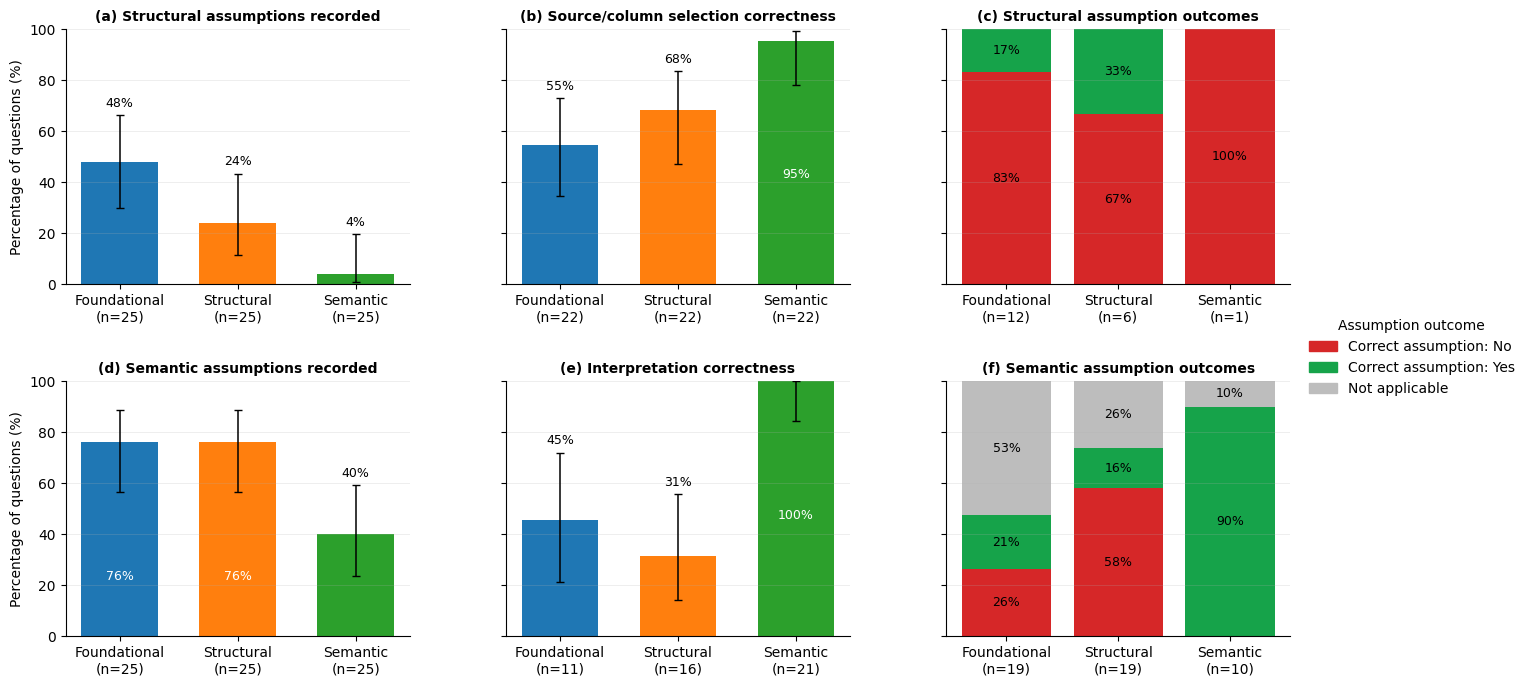

In [283]:
# ---- config ----
COND_ORDER = ["raw", "struct", "sem"]
COND_LABEL = {"raw": "Foundational", "struct": "Structural", "sem": "Semantic"}

# condition colors for PROCESS MEASURE bars
COLORS_COND = {"raw": "#1f77b4", "struct": "#ff7f0e", "sem": "#2ca02c"}

# denominators to show under ticks for PROCESS MEASURES
N_TICK = {
    "structural_assumption_made": {"raw": 25, "struct": 25, "sem": 25},
    "semantic_assumption_made":   {"raw": 25, "struct": 25, "sem": 25},
    "source_correct":             {"raw": 22, "struct": 22, "sem": 22},
    "interpretation_correct":     {"raw": 11, "struct": 16, "sem": 21},
}

# panels (var, title)
MEASURES = [
    ("structural_assumption_made", "(a) Structural assumptions recorded"),
    ("source_correct",             "(b) Source/column selection correctness"),
    ("semantic_assumption_made",   "(d) Semantic assumptions recorded"),
    ("interpretation_correct",     "(e) Interpretation correctness"),
]

# ---- helpers for process-measure panels ----
def get_row(var, cond):
    d = process_rates[
        (process_rates["process_variable"].astype(str) == var) &
        (process_rates["condition"].astype(str) == cond)
    ]
    if len(d) != 1:
        raise ValueError(f"Expected exactly 1 row for ({var}, {cond}); found {len(d)}.")
    r = d.iloc[0]
    n = int(r["n_classifiable"])
    n_yes = int(r["n_yes"])
    lo = float(r["wilson95_low"]) * 100.0
    hi = float(r["wilson95_high"]) * 100.0
    pct = (n_yes / n * 100.0) if n > 0 else np.nan
    return {"n_yes": n_yes, "n": n, "pct": pct, "lo": lo, "hi": hi}

def clean_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def plot_process_measure(ax, var, title):
    vals, lo, hi = [], [], []
    for c in COND_ORDER:
        r = get_row(var, c)
        vals.append(r["pct"])
        lo.append(r["lo"])
        hi.append(r["hi"])

    vals = np.array(vals, dtype=float)
    lo = np.array(lo, dtype=float)
    hi = np.array(hi, dtype=float)
    yerr = np.vstack([vals - lo, hi - vals])

    x = np.arange(len(COND_ORDER))
    bar_w = 0.65

    ax.bar(
        x, vals, width=bar_w,
        color=[COLORS_COND[c] for c in COND_ORDER],
        edgecolor="none"
    )
    ax.errorbar(
        x, vals, yerr=yerr,
        fmt="none", ecolor="black",
        capsize=3, elinewidth=1.1
    )

    # % labels (place inside if near top)
    TOP_SWITCH = 92
    LABEL_PAD = 2.0
    for i, yi in enumerate(vals):
        upper = yerr[1, i]
        y_above = yi + upper + LABEL_PAD
        if yi >= TOP_SWITCH or y_above >= 90:
            ax.text(i, yi - 50, f"{yi:.0f}%", ha="center", va="top", fontsize=9, color="white")
        else:
            ax.text(i, y_above, f"{yi:.0f}%", ha="center", va="bottom", fontsize=9, color="black")

    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{COND_LABEL[c]}\n(n={N_TICK[var][c]})" for c in COND_ORDER], ha="center")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.grid(axis="y", linewidth=0.6, alpha=0.25)
    clean_spines(ax)

# ----------------------------
# Assumption outcome panels (100% stacked; conditional on assumption=yes)
# ----------------------------
STACK_ORDER = ["Correct assumption: No", "Correct assumption: Yes", "Not applicable"]
COLORS_OUTCOME = {
    "Correct assumption: No":  "#d62728",  # red
    "Correct assumption: Yes": "#16A34A",  # green
    "Not applicable":          "#bdbdbd",  # grey
}
LABEL_THRESHOLD = 8  

YES = {"yes","y","true","1"}
NO  = {"no","n","false","0"}
NA  = {"na","n/a","nan","", "none", "not applicable", "not_applicable", "n.a."}

def norm_yes_no_na(s: pd.Series) -> pd.Series:
    v = s.astype(str).str.strip().str.lower()
    v = v.replace({"n/a":"na","nan":"na", "": "na"})
    return v.map(lambda x: "yes" if x in YES else ("no" if x in NO else ("na" if x in NA else x)))

def summarize_assump_outcomes_100(df_wide: pd.DataFrame, assump_base: str, outcome_base: str) -> pd.DataFrame:
    rows = []
    for c in COND_ORDER:
        a_col = f"{assump_base}_{c}"
        o_col = f"{outcome_base}_{c}"
        if a_col not in df_wide.columns or o_col not in df_wide.columns:
            raise ValueError(f"Missing required columns: {a_col} and/or {o_col}")

        a = norm_yes_no_na(df_wide[a_col])
        o = norm_yes_no_na(df_wide[o_col])

        m_yes = (a == "yes")
        o_sub = o[m_yes].copy()
        o_sub = o_sub.where(o_sub.isin(["yes","no","na"]), other="na")

        n_assump_yes = int(m_yes.sum())
        n_yes = int((o_sub == "yes").sum())
        n_no  = int((o_sub == "no").sum())
        n_na  = int((o_sub == "na").sum())

        denom = n_assump_yes if n_assump_yes > 0 else np.nan

        rows.append({
            "condition": c,
            "n_assumption_yes": n_assump_yes,
            "pct_no":  (100*n_no/denom)  if n_assump_yes > 0 else 0.0,
            "pct_yes": (100*n_yes/denom) if n_assump_yes > 0 else 0.0,
            "pct_na":  (100*n_na/denom)  if n_assump_yes > 0 else 0.0,
        })
    return pd.DataFrame(rows)

def plot_stacked_100(ax, df_sum: pd.DataFrame, title: str, panel_tag: str):
    x = np.arange(len(COND_ORDER))
    bottom = np.zeros(len(COND_ORDER), dtype=float)

    vals_map = {
        "Correct assumption: No":  df_sum["pct_no"].values.astype(float),
        "Correct assumption: Yes": df_sum["pct_yes"].values.astype(float),
        "Not applicable":          df_sum["pct_na"].values.astype(float),
    }

    for k in STACK_ORDER:
        ax.bar(
            x, vals_map[k],
            bottom=bottom,
            color=COLORS_OUTCOME[k],
            edgecolor="none",
            label=k
        )
        bottom += vals_map[k]

    # segment labels
    bottom2 = np.zeros(len(COND_ORDER), dtype=float)
    for k in STACK_ORDER:
        vals = vals_map[k]
        for j in range(len(COND_ORDER)):
            if vals[j] >= LABEL_THRESHOLD:
                ax.text(j, bottom2[j] + vals[j]/2, f"{vals[j]:.0f}%", ha="center", va="center", fontsize=9)
        bottom2 += vals

    ticklabs = []
    for c in COND_ORDER:
        n_assump = int(df_sum.loc[df_sum["condition"] == c, "n_assumption_yes"].iloc[0])
        ticklabs.append(f"{COND_LABEL[c]}\n(n={n_assump})")

    ax.set_xticks(x)
    ax.set_xticklabels(ticklabs, ha="center")
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_title(f"{panel_tag} {title}", fontsize=10, fontweight="bold")
    clean_spines(ax)

# ----------------------------
# Load df_wide if needed
# ----------------------------
# If you already have df_wide loaded, this won't run.
# WIDE_PATH = "/Users/feline.mollerus/Documents/jbhi_llm_paper/buddi_project/data/processed/buddi_paper_question_eval_wide.csv"
# if "df_wide" not in globals():
#     df_wide = pd.read_csv(WIDE_PATH)

assump_struct = summarize_assump_outcomes_100(df_wide, "structural_assumption_made", "source_correct")
assump_sem    = summarize_assump_outcomes_100(df_wide, "semantic_assumption_made",   "interpretation_correct")

# ----------------------------
# Build 2×3 panel (a–f)
# ----------------------------
fig, axes = plt.subplots(2, 3, figsize=(15.8, 8.2), sharey=True, constrained_layout=False)
fig.subplots_adjust(top=0.90, bottom=0.16, wspace=0.28, hspace=0.38)

# Row 1
plot_process_measure(axes[0, 0], "structural_assumption_made", "(a) Structural assumptions recorded")
plot_process_measure(axes[0, 1], "source_correct",             "(b) Source/column selection correctness")
plot_stacked_100(
    axes[0, 2], assump_struct,
    title="Structural assumption outcomes",
    panel_tag="(c)"
)

# Row 2
plot_process_measure(axes[1, 0], "semantic_assumption_made",   "(d) Semantic assumptions recorded")
plot_process_measure(axes[1, 1], "interpretation_correct",     "(e) Interpretation correctness")
plot_stacked_100(
    axes[1, 2], assump_sem,
    title="Semantic assumption outcomes",
    panel_tag="(f)"
)

# y-label only on left column
axes[0, 0].set_ylabel("Percentage of questions (%)")
axes[1, 0].set_ylabel("Percentage of questions (%)")

# ----------------------------
# Legends (two separate, non-conflicting)
# ----------------------------
# Legend 1: condition colors (for panels a, b, d, e)
# cond_handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS_COND[c]) for c in COND_ORDER]
# cond_labels  = [COND_LABEL[c] for c in COND_ORDER]
# fig.legend(
#     cond_handles, cond_labels,
#     loc="upper center", ncol=3, frameon=False,
#     bbox_to_anchor=(0.5, 0.98), title="Interoperability level"
# )

# Legend 2: outcome stack colors (for panels c, f)
out_handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS_OUTCOME[k]) for k in STACK_ORDER]
fig.legend(
    out_handles, STACK_ORDER,
    loc="right", frameon=False,
    bbox_to_anchor=(1.05, 0.5), title="Assumption outcome"
)

# ----------------------------
# Save
# ----------------------------
OUT_MAIN_FIG = Path(OUT_MAIN_FIG)
OUT_MAIN_FIG.mkdir(parents=True, exist_ok=True)

base = OUT_MAIN_FIG / "Fig4_process_measures_and_assumption_outcomes_2x3"
fig.savefig(str(base) + ".pdf", bbox_inches="tight", pad_inches=0.2)
fig.savefig(str(base) + ".png", dpi=600, bbox_inches="tight", pad_inches=0.2)
print("Saved:", str(base) + ".pdf")
print("Saved:", str(base) + ".png")


## Main Table I — At-a-glance conditions (accuracy + efficiency) and accuracy

Rows: raw / struct / sem

Columns  Conditions:
- Accuracy (n/N, %) + Wilson 95% CI
- Paired accuracy tests: McNemar p (Holm-adjusted) + improved/worsened discordants
- Median tokens (IQR)
- Median TTFT (IQR)

Paired accuracy comparisons (McNemar + Holm only) and risk differences

Saved to `main/tables/`.

In [ ]:
COND_ORDER = ["raw", "struct", "sem"]
COND_LABEL = {"raw": "Raw", "struct": "Structural", "sem": "Semantic"}

COMP_ORDER = ["raw_vs_struct", "struct_vs_sem", "raw_vs_sem"]
COMP_LABEL = {
    "raw_vs_struct": "Structural vs Raw",
    "struct_vs_sem": "Semantic vs Structural",
    "raw_vs_sem": "Semantic vs Raw",
}

# -------------------------
# Formatters
# -------------------------
def fmt_ci(lo, hi, digits=3):
    if pd.isna(lo) or pd.isna(hi): return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"

def fmt_num(x, digits=0):
    if pd.isna(x): return ""
    x = float(x)
    if digits == 0:
        return f"{x:,.0f}"
    return f"{x:,.{digits}f}"

def fmt_iqr(q1, q3, digits=0):
    if pd.isna(q1) or pd.isna(q3): return ""
    return f"[{fmt_num(q1, digits)}, {fmt_num(q3, digits)}]"

def fmt_mean_sd(mean, sd, digits=0):
    if pd.isna(mean) or pd.isna(sd): return ""
    return f"{fmt_num(mean, digits)} ({fmt_num(sd, digits)})"

def fmt_p(p):
    if pd.isna(p): return ""
    p = float(p)
    if p < 0.001:
        return f"{p:.2e}"
    return f"{p:.3f}"

# -------------------------
# Table Ia: condition summary
# -------------------------
acc_map = {r["condition"]: r for _, r in accuracy_overall.iterrows()}

tok = tokens_overall[tokens_overall["stratum"]=="overall"].set_index("condition")
ttf = ttft_overall[ttft_overall["stratum"]=="overall"].set_index("condition")

rows = []
for c in COND_ORDER:
    r = acc_map[c]
    n_correct = int(r["n_correct"])
    n_total   = int(r["n_questions"])
    acc_pct   = 100.0 * float(r["accuracy"])

    rows.append({
        "Representation": COND_LABEL[c],
        "Accuracy n/N": f"{n_correct}/{n_total}",
        "Accuracy %": round(acc_pct, 1),
        "Accuracy (Wilson 95% CI)": fmt_ci(float(r["wilson95_low"]), float(r["wilson95_high"]), digits=3),

        "Tokens median": fmt_num(tok.loc[c, "median"], 0),
        "Tokens IQR": fmt_iqr(tok.loc[c, "q1"], tok.loc[c, "q3"], digits=0),
        "Tokens mean (SD)": fmt_mean_sd(tok.loc[c, "mean"], tok.loc[c, "sd"], digits=0),

        "TTFT median (ms)": fmt_num(ttf.loc[c, "median"], 0),
        "TTFT IQR (ms)": fmt_iqr(ttf.loc[c, "q1"], ttf.loc[c, "q3"], digits=0),
        "TTFT mean (SD) (ms)": fmt_mean_sd(ttf.loc[c, "mean"], ttf.loc[c, "sd"], digits=0),
    })

tableIa = pd.DataFrame(rows)
display(tableIa)
tableIa.to_csv(OUT_MAIN_TAB / "TableIa_conditions.csv", index=False)
print("Saved Table Ia.")

# -------------------------
# Table Ib: paired accuracy comparisons (McNemar + Holm only) and risk differences
# -------------------------
mcn = mcnemar_holm.copy()
rd  = risk_diffs.copy()

# --- Map risk_diffs comparison labels to McNemar labels ---
rd_map = {
    "struct_minus_raw": "raw_vs_struct",
    "sem_minus_struct": "struct_vs_sem",
    "sem_minus_raw": "raw_vs_sem",
}
rd["comparison_mcn"] = rd["comparison"].map(rd_map)

# --- Order ---
mcn["comparison"] = pd.Categorical(mcn["comparison"], categories=COMP_ORDER, ordered=True)
mcn = mcn.sort_values("comparison").reset_index(drop=True)

# --- Merge (McNemar comparison key with mapped risk-diff key) ---
tableIb = mcn.merge(
    rd[["comparison_mcn", "paired_risk_difference", "boot95_low", "boot95_high"]],
    left_on="comparison", right_on="comparison_mcn", how="left"
)

# --- Format effect size in percentage points ---
tableIb["Risk difference (pp)"] = (100.0 * tableIb["paired_risk_difference"].astype(float)).map(lambda v: f"{v:+.0f}")
tableIb["Risk difference 95% CI (pp)"] = tableIb.apply(
    lambda row: f"[{100.0*float(row['boot95_low']):+.0f}, {100.0*float(row['boot95_high']):+.0f}]"
    if (pd.notna(row["boot95_low"]) and pd.notna(row["boot95_high"])) else "",
    axis=1
)

# --- Output table (paper-facing) ---
tableIb_out = pd.DataFrame({
    "Comparison": tableIb["comparison"].map(COMP_LABEL),
    "Improved (A incorrect → B correct)": tableIb["improved"].astype(int),
    "Worsened (A correct → B incorrect)": tableIb["worsened"].astype(int),
    "Risk difference (pp)": tableIb["Risk difference (pp)"],
    "Risk difference 95% CI (pp)": tableIb["Risk difference 95% CI (pp)"],
    "McNemar p (unadj)": tableIb["p_unadj"].map(fmt_p),
    "McNemar p (Holm)": tableIb["p_holm"].map(fmt_p),
})

display(tableIb_out)
tableIb_out.to_csv(OUT_MAIN_TAB / "TableIb_paired_accuracy.csv", index=False)
print("Saved Table Ib (with risk differences).")

,Representation,Accuracy n/N,Accuracy %,Accuracy (Wilson 95% CI),Tokens median,Tokens IQR,Tokens mean (SD),TTFT median (ms),TTFT IQR (ms),TTFT mean (SD) (ms)
0,Raw,8/25,32.0,"[0.172, 0.516]","202,736","[123,247, 305,055]","254,651 (176,724)","2,142","[1,991, 3,175]","2,438 (599)"
1,Structural,10/25,40.0,"[0.234, 0.593]","36,170","[21,017, 59,221]","45,155 (35,557)","1,123","[994, 3,162]","2,243 (1,849)"
2,Semantic,24/25,96.0,"[0.805, 0.993]","46,153","[22,804, 71,258]","56,222 (42,048)","1,307","[1,051, 3,435]","1,987 (1,172)"


Saved Table Ia.


,Comparison,Improved (A incorrect → B correct),Worsened (A correct → B incorrect),Risk difference (pp),Risk difference 95% CI (pp),McNemar p (unadj),McNemar p (Holm)
0,Structural vs Raw,2,0,+8,"[+0, +20]",0.500,0.500
1,Semantic vs Structural,14,0,+56,"[+36, +76]",1.22e-04,2.44e-04
2,Semantic vs Raw,16,0,+64,"[+44, +84]",3.05e-05,9.16e-05


Saved Table Ib (with risk differences).


In [ ]:
def fmt_ci_num(lo, hi, digits=0):
    if pd.isna(lo) or pd.isna(hi): return ""
    return f"[{fmt_num(lo, digits)}, {fmt_num(hi, digits)}]"

def fmt_ci_ratio(lo, hi, digits=2):
    if pd.isna(lo) or pd.isna(hi): return ""
    return f"[{float(lo):.{digits}f}, {float(hi):.{digits}f}]"

tp = tokens_paired.copy()
tp = tp[(tp["metric"] == "tokens") & (tp["stratum"] == "overall")].copy()
tp_map = {r["comparison"]: r for _, r in tp.iterrows()}

rows = []

# 1) raw vs structural: want raw/struct and raw-struct
r = tp_map["struct_minus_raw"]  # provides struct - raw, and struct/raw
# raw/struct = 1/(struct/raw)
ratio = 1.0 / float(r["median_of_per_question_ratios_B_over_A"])
ratio_lo = 1.0 / float(r["ratio_boot95_high"])  # invert CI endpoints
ratio_hi = 1.0 / float(r["ratio_boot95_low"])
diff = -float(r["median_paired_diff_B_minus_A"])  # raw - struct
diff_lo = -float(r["diff_boot95_high"])
diff_hi = -float(r["diff_boot95_low"])

rows.append({
    "Comparison": "Raw / Structural",
    "Median of per-question ratios": f"{ratio:.2f}",
    "Ratio 95% CI": fmt_ci_ratio(ratio_lo, ratio_hi, digits=2),
    "Paired median difference (tokens)": fmt_num(diff, 0),
    "Difference 95% CI (tokens)": fmt_ci_num(diff_lo, diff_hi, digits=0),
})

# 2) raw vs semantic: want raw/sem and raw-sem
r = tp_map["sem_minus_raw"]  # provides sem - raw, and sem/raw
ratio = 1.0 / float(r["median_of_per_question_ratios_B_over_A"])  # raw/sem
ratio_lo = 1.0 / float(r["ratio_boot95_high"])
ratio_hi = 1.0 / float(r["ratio_boot95_low"])
diff = -float(r["median_paired_diff_B_minus_A"])  # raw - sem
diff_lo = -float(r["diff_boot95_high"])
diff_hi = -float(r["diff_boot95_low"])

rows.append({
    "Comparison": "Raw / Semantic",
    "Median of per-question ratios": f"{ratio:.2f}",
    "Ratio 95% CI": fmt_ci_ratio(ratio_lo, ratio_hi, digits=2),
    "Paired median difference (tokens)": fmt_num(diff, 0),
    "Difference 95% CI (tokens)": fmt_ci_num(diff_lo, diff_hi, digits=0),
})

# 3) structural vs semantic: want structural/semantic and structural-semantic
r = tp_map["sem_minus_struct"]  # provides sem - struct, and sem/struct
ratio = 1.0 / float(r["median_of_per_question_ratios_B_over_A"])  # struct/sem
ratio_lo = 1.0 / float(r["ratio_boot95_high"])
ratio_hi = 1.0 / float(r["ratio_boot95_low"])
diff = -float(r["median_paired_diff_B_minus_A"])  # struct - sem
diff_lo = -float(r["diff_boot95_high"])
diff_hi = -float(r["diff_boot95_low"])

rows.append({
    "Comparison": "Structural / Semantic",
    "Median of per-question ratios": f"{ratio:.2f}",
    "Ratio 95% CI": fmt_ci_ratio(ratio_lo, ratio_hi, digits=2),
    "Paired median difference (tokens)": fmt_num(diff, 0),
    "Difference 95% CI (tokens)": fmt_ci_num(diff_lo, diff_hi, digits=0),
})

tableIc = pd.DataFrame(rows)

display(tableIc)
tableIc.to_csv(OUT_MAIN_TAB / "TableIc_paired_token_contrasts.csv", index=False)
print("Saved Table Ic.")


,Comparison,Median of per-question ratios,Ratio 95% CI,Paired median difference (tokens),Difference 95% CI (tokens)
0,Raw / Structural,5.96,"[4.67, 6.37]","188,056","[101,748, 247,108]"
1,Raw / Semantic,5.34,"[3.45, 5.90]","155,741","[98,908, 223,082]"
2,Structural / Semantic,0.93,"[0.62, 0.99]","-1,059","[-24,026, -275]"


Saved Table Ic.


## Main Table II — Process measures and mechanism links (Stage 1 + exploratory links)

Includes:
- Stage-1 process rates with Wilson CIs and classifiable denominators
- Paired McNemar (paired complete-case): paired N, improved/worsened, p-value (descriptive)
- Exploratory Fisher links within condition:
  - correctness vs source_correct
  - correctness vs interpretation_correct

Saved to `main/tables/`.

In [ ]:
# Keep compact outputs for main table, but retain denominators and link counts.

tableII_rates = process_rates.copy()
tableII_rates["condition"] = tableII_rates["condition"].astype(str)

tableII_pairs = process_paired_mcnemar.copy()

tableII_links = process_links.copy()
tableII_links["condition"] = tableII_links["condition"].astype(str)

# Save as separate CSVs (cleaner for manuscript assembly)
tableII_rates.to_csv(OUT_MAIN_TAB / "TableII_process_rates.csv", index=False)
tableII_pairs.to_csv(OUT_MAIN_TAB / "TableII_process_paired_mcnemar.csv", index=False)
tableII_links.to_csv(OUT_MAIN_TAB / "TableII_process_links_fisher.csv", index=False)

print("Saved Table II components.")


Saved Table II components.


In [ ]:
PROC_LABEL = {
    "structural_assumption_made": "Structural assumption rate",
    "semantic_assumption_made": "Semantic assumption rate",
    "source_correct": "Correct source/column rate",
    "interpretation_correct": "Correct interpretation rate",
}

def fmt_pct(x, digits=1):
    return "" if pd.isna(x) else f"{100*float(x):.{digits}f}"

def fmt_ci_pct(lo, hi, digits=1):
    if pd.isna(lo) or pd.isna(hi):
        return ""
    return f"[{100*float(lo):.{digits}f}, {100*float(hi):.{digits}f}]"

# -------------------------
# Table IIa: process rates
# -------------------------
rates = process_rates.copy()
rates["condition"] = rates["condition"].astype(str)

# map readable labels
rates["Representation"] = rates["condition"].map(COND_LABEL)
rates["Measure"] = rates["process_variable"].map(PROC_LABEL).fillna(rates["process_variable"])

# create compact rate + CI columns
rates["Rate (%)"] = rates["rate"].apply(lambda v: fmt_pct(v, 1))
rates["Wilson 95% CI (%)"] = rates.apply(lambda r: fmt_ci_pct(r["wilson95_low"], r["wilson95_high"], 1), axis=1)

# keep key denominators
keep_cols = ["Measure", "Representation", "n_classifiable", "n_yes", "Rate (%)", "Wilson 95% CI (%)"]
tableII_rates = rates[keep_cols].copy()

# order rows: by Measure then Raw/Structural/Semantic
tableII_rates["Representation"] = pd.Categorical(tableII_rates["Representation"],
                                                 categories=[COND_LABEL[c] for c in COND_ORDER],
                                                 ordered=True)
tableII_rates = tableII_rates.sort_values(["Measure", "Representation"]).reset_index(drop=True)

# -------------------------
# Table IIb: paired McNemar (process vars) — robust to column names
# -------------------------
pairs = process_paired_mcnemar.copy()

comp_map = {
    "raw_vs_struct": "Raw vs Structural",
    "struct_vs_sem": "Structural vs Semantic",
    "raw_vs_sem": "Raw vs Semantic",
}
pairs["Comparison"] = pairs["comparison"].astype(str).map(comp_map).fillna(pairs["comparison"].astype(str))
pairs["Measure"] = pairs["process_variable"].map(PROC_LABEL).fillna(pairs["process_variable"])

# find the paired-N column name
n_col = None
for cand in ["n_pairs", "n", "paired_n", "n_used", "n_complete_pairs"]:
    if cand in pairs.columns:
        n_col = cand
        break
if n_col is None:
    raise KeyError(f"Could not find a paired-N column in process_paired_mcnemar. Columns: {list(pairs.columns)}")

# find the McNemar p-value column name
p_col = None
for cand in ["mcnemar_p", "p_value", "p", "mcnemar_pvalue"]:
    if cand in pairs.columns:
        p_col = cand
        break
if p_col is None:
    raise KeyError(f"Could not find a McNemar p-value column in process_paired_mcnemar. Columns: {list(pairs.columns)}")

# pick discordant counts if present
disc_cols = []
for cand in ["improved", "worsened", "n01", "n10", "discordant_yes_to_no", "discordant_no_to_yes"]:
    if cand in pairs.columns:
        disc_cols.append(cand)

tableII_pairs = pairs[["Measure", "Comparison", n_col] + disc_cols + [p_col]].copy()
tableII_pairs = tableII_pairs.rename(columns={n_col: "paired_N", p_col: "mcnemar_p"})

# order by Measure then comparisons
tableII_pairs["Comparison"] = pd.Categorical(
    tableII_pairs["Comparison"],
    categories=["Raw vs Structural", "Structural vs Semantic", "Raw vs Semantic"],
    ordered=True
)
tableII_pairs = tableII_pairs.sort_values(["Measure", "Comparison"]).reset_index(drop=True)


# -------------------------
# Table IIc: links to correctness (Fisher 2×2 within condition)
# -------------------------
links = process_links.copy()
links["condition"] = links["condition"].astype(str)

links["Representation"] = links["condition"].map(COND_LABEL)
links["Process variable"] = links["process_variable"].map(PROC_LABEL).fillna(links["process_variable"])

# orename key fields if present
rename_map = {
    "p_value": "Fisher p-value",
    "method": "Test",
    "n": "n (classifiable)",
    "p_correct_given_proc_yes": "P(correct | process yes)",
    "p_correct_given_proc_no": "P(correct | process no)",
    "table_proc_yes_correct": "Yes & Correct",
    "table_proc_yes_incorrect": "Yes & Incorrect",
    "table_proc_no_correct": "No & Correct",
    "table_proc_no_incorrect": "No & Incorrect",
}
for k, v in rename_map.items():
    if k in links.columns:
        links = links.rename(columns={k: v})

# keep a compact, auditable set of columns
link_cols = ["Representation", "Process variable"]
for c in ["n (classifiable)", "Test", "Fisher p-value",
          "P(correct | process yes)", "P(correct | process no)",
          "Yes & Correct", "Yes & Incorrect", "No & Correct", "No & Incorrect"]:
    if c in links.columns:
        link_cols.append(c)

tableII_links = links[link_cols].copy()

# enforce condition order
tableII_links["Representation"] = pd.Categorical(tableII_links["Representation"],
                                                 categories=[COND_LABEL[c] for c in COND_ORDER],
                                                 ordered=True)
tableII_links = tableII_links.sort_values(["Process variable", "Representation"]).reset_index(drop=True)

# -------------------------
# Save as separate CSVs
# -------------------------
tableII_rates.to_csv(OUT_MAIN_TAB / "TableIIa_process_rates.csv", index=False)
tableII_pairs.to_csv(OUT_MAIN_TAB / "TableIIb_process_paired_mcnemar.csv", index=False)
tableII_links.to_csv(OUT_MAIN_TAB / "TableIIc_process_links_fisher.csv", index=False)

display(tableII_rates)
display(tableII_pairs)
display(tableII_links)

print("Saved Table IIa/IIb/IIc.")


,Measure,Representation,n_classifiable,n_yes,Rate (%),Wilson 95% CI (%)
0,Correct interpretation rate,Raw,11,5,45.5,"[21.3, 72.0]"
1,Correct interpretation rate,Structural,16,5,31.2,"[14.2, 55.6]"
2,Correct interpretation rate,Semantic,21,21,100.0,"[84.5, 100.0]"
3,Correct source/column rate,Raw,22,12,54.5,"[34.7, 73.1]"
4,Correct source/column rate,Structural,22,15,68.2,"[47.3, 83.6]"
5,Correct source/column rate,Semantic,22,21,95.5,"[78.2, 99.2]"
6,Semantic assumption rate,Raw,25,19,76.0,"[56.6, 88.5]"
7,Semantic assumption rate,Structural,25,19,76.0,"[56.6, 88.5]"
8,Semantic assumption rate,Semantic,25,10,40.0,"[23.4, 59.3]"
9,Structural assumption rate,Raw,25,12,48.0,"[30.0, 66.5]"


,Measure,Comparison,paired_N,improved,worsened,mcnemar_p
0,Correct interpretation rate,Raw vs Structural,10,0,0,1.000000
1,Correct interpretation rate,Structural vs Semantic,16,11,0,0.000977
2,Correct interpretation rate,Raw vs Semantic,11,6,0,0.031250
3,Correct source/column rate,Raw vs Structural,22,4,1,0.375000
4,Correct source/column rate,Structural vs Semantic,22,6,0,0.031250
5,Correct source/column rate,Raw vs Semantic,22,9,0,0.003906
6,Semantic assumption rate,Raw vs Structural,25,1,1,1.000000
7,Semantic assumption rate,Structural vs Semantic,25,1,10,0.011719
8,Semantic assumption rate,Raw vs Semantic,25,2,11,0.022461
9,Structural assumption rate,Raw vs Structural,25,1,7,0.070312


,Representation,Process variable,n (classifiable),Test,Fisher p-value,P(correct | process yes),P(correct | process no),Yes & Correct,Yes & Incorrect,No & Correct,No & Incorrect
0,Raw,Correct interpretation rate,11,fisher_exact_2x2,0.002165,1.000000,0.0,5,0,0,6
1,Structural,Correct interpretation rate,16,fisher_exact_2x2,0.000229,1.000000,0.0,5,0,0,11
2,Semantic,Correct interpretation rate,21,skipped_degenerate_table,NaN,1.000000,NaN,21,0,0,0
3,Raw,Correct source/column rate,22,fisher_exact_2x2,0.039645,0.416667,0.0,5,7,0,10
4,Structural,Correct source/column rate,22,fisher_exact_2x2,0.051283,0.466667,0.0,7,8,0,7
5,Semantic,Correct source/column rate,22,fisher_exact_2x2,0.045455,1.000000,0.0,21,0,0,1


Saved Table IIa/IIb/IIc.


In [ ]:
##NEw table II
COND_ORDER = ["raw", "struct", "sem"]
COND_LABEL = {"raw": "Raw", "struct": "Structural", "sem": "Semantic"}

PROC_ORDER = [
    "structural_assumption_made",
    "semantic_assumption_made",
    "source_correct",
    "interpretation_correct",
]
PROC_LABEL = {
    "structural_assumption_made": "Structural assumption rate",
    "semantic_assumption_made": "Semantic assumption rate",
    "source_correct": "Correct source/column rate",
    "interpretation_correct": "Correct interpretation rate",
}

COMP_ORDER = ["raw_vs_struct", "struct_vs_sem", "raw_vs_sem"]
COMP_LABEL = {
    "raw_vs_struct": "Raw vs Structural",
    "struct_vs_sem": "Structural vs Semantic",
    "raw_vs_sem": "Raw vs Semantic",
}

def fmt_rate_cell(n_yes, n, rate, lo, hi, digits=1):
    if pd.isna(n) or int(n) == 0:
        return "NA"
    return f"{int(n_yes)}/{int(n)}; {100*float(rate):.{digits}f}% [{100*float(lo):.{digits}f}, {100*float(hi):.{digits}f}]"

def fmt_p_cell(p, n_pairs):
    if pd.isna(p) or pd.isna(n_pairs) or int(n_pairs) == 0:
        return "NA"
    return f"{float(p):.4g} (N={int(n_pairs)})"

# -------------------------
# rates lookup
# -------------------------
rates = process_rates.copy()
rates["condition"] = rates["condition"].astype(str)
rates = rates[rates["process_variable"].isin(PROC_ORDER)].copy()

rate_map = {(r["process_variable"], r["condition"]): r for _, r in rates.iterrows()}

# -------------------------
# paired McNemar lookup
# -------------------------
pairs = process_paired_mcnemar.copy()
pairs["comparison"] = pairs["comparison"].astype(str)
pairs = pairs[pairs["process_variable"].isin(PROC_ORDER)].copy()

n_col = None
for cand in ["paired_n", "n_pairs", "paired_N", "n", "n_used", "n_complete_pairs"]:
    if cand in pairs.columns:
        n_col = cand
        break
if n_col is None:
    raise KeyError(f"Could not find paired-N column in process_paired_mcnemar. Columns: {list(pairs.columns)}")

# p-value column 
p_col = None
for cand in ["p_value", "mcnemar_p", "p", "mcnemar_pvalue"]:
    if cand in pairs.columns:
        p_col = cand
        break
if p_col is None:
    raise KeyError(f"Could not find McNemar p-value column in process_paired_mcnemar. Columns: {list(pairs.columns)}")

pair_map = {(r["process_variable"], r["comparison"]): r for _, r in pairs.iterrows()}

# -------------------------
# assemble Table II
# -------------------------
rows = []
for pv in PROC_ORDER:
    row = {"Measure": PROC_LABEL.get(pv, pv)}

    # per-condition cells
    for c in COND_ORDER:
        r = rate_map.get((pv, c), None)
        row[COND_LABEL[c]] = "NA" if r is None else fmt_rate_cell(
            r.get("n_yes", np.nan),
            r.get("n_classifiable", np.nan),
            r.get("rate", np.nan),
            r.get("wilson95_low", np.nan),
            r.get("wilson95_high", np.nan),
            digits=1
        )

    for comp in COMP_ORDER:
        pr = pair_map.get((pv, comp), None)
        row[COMP_LABEL[comp]] = "NA" if pr is None else fmt_p_cell(pr.get(p_col, np.nan), pr.get(n_col, np.nan))

    rows.append(row)

tableII = pd.DataFrame(rows)
tableII = tableII[["Measure", "Raw", "Structural", "Semantic",
                   "Raw vs Structural", "Structural vs Semantic", "Raw vs Semantic"]]

display(tableII)
tableII.to_csv(OUT_MAIN_TAB / "TableII_process_stage1.csv", index=False)
print("Saved Table II:", OUT_MAIN_TAB / "TableII_process_stage1.csv")


,Measure,Raw,Structural,Semantic,Raw vs Structural,Structural vs Semantic,Raw vs Semantic
0,Structural assumption rate,"12/25; 48.0% [30.0, 66.5]","6/25; 24.0% [11.5, 43.4]","1/25; 4.0% [0.7, 19.5]",0.07031 (N=25),0.0625 (N=25),0.0009766 (N=25)
1,Semantic assumption rate,"19/25; 76.0% [56.6, 88.5]","19/25; 76.0% [56.6, 88.5]","10/25; 40.0% [23.4, 59.3]",1 (N=25),0.01172 (N=25),0.02246 (N=25)
2,Correct source/column rate,"12/22; 54.5% [34.7, 73.1]","15/22; 68.2% [47.3, 83.6]","21/22; 95.5% [78.2, 99.2]",0.375 (N=22),0.03125 (N=22),0.003906 (N=22)
3,Correct interpretation rate,"5/11; 45.5% [21.3, 72.0]","5/16; 31.2% [14.2, 55.6]","21/21; 100.0% [84.5, 100.0]",1 (N=10),0.0009766 (N=16),0.03125 (N=11)


Saved Table II: ../outputs/buddi_paper/v1/main/tables/TableII_process_stage1.csv


## Step 6 — Verify outputs and write a release manifest

We list the files produced and write a small JSON manifest recording:
- input canonical table names
- output filenames and timestamps


In [ ]:
def list_dir(p: Path):
    return sorted([x.name for x in p.glob("*")])

manifest = {
    "paper_slug": PAPER_SLUG,
    "release_id": RELEASE_ID,
    "run_id": RUN_ID,
    "created_at": NOW,
    "analysis_dir": str(ANALYSIS_DIR),
    "main_figures": list_dir(OUT_MAIN_FIG),
    "main_tables": list_dir(OUT_MAIN_TAB),
    "supp_figures": list_dir(OUT_SUP_FIG),
    "supp_tables": list_dir(OUT_SUP_TAB),
}

with open(OUT_LOG / f"{PAPER_SLUG}_{RELEASE_ID}_{RUN_ID}_manifest_05.json", "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("\nMAIN FIGURES:", list_dir(OUT_MAIN_FIG))
print("\nMAIN TABLES:", list_dir(OUT_MAIN_TAB))
print("\nSUPP FIGURES:", list_dir(OUT_SUP_FIG))
print("\nSUPP TABLES:", list_dir(OUT_SUP_TAB))
print("\nWrote manifest to:", OUT_LOG)



MAIN FIGURES: ['Fig1_accuracy_overall_and_by_complexity.pdf', 'Fig1_accuracy_overall_and_by_complexity.png', 'Fig2_tokens_by_condition.pdf', 'Fig2_tokens_by_condition.png', 'Fig3_error_profiles_stacked.pdf', 'Fig3_error_profiles_stacked.png']

MAIN TABLES: ['TableII_process_and_links.csv', 'TableII_process_links_fisher.csv', 'TableII_process_paired_mcnemar.csv', 'TableII_process_rates.csv', 'TableI_main_summary.csv', 'TableIa_conditions.csv', 'TableIb_paired_accuracy.csv']

SUPP FIGURES: ['FigS1_tokens_by_complexity.pdf', 'FigS1_tokens_by_complexity.png', 'FigS2_TTFT_by_complexity.pdf', 'FigS2_TTFT_by_complexity.png', 'FigS3_transitions_alluvial.pdf', 'FigS3_transitions_alluvial.png', 'FigS_stack_correct_by_complexity_within_condition.pdf', 'FigS_stack_correct_by_complexity_within_condition.png', 'FigS_stack_correct_by_complexity_within_condition_pct.pdf', 'FigS_stack_correct_by_complexity_within_condition_pct.png']

SUPP TABLES: ['TableS1_accuracy_by_complexity.csv', 'TableS2_errors_